In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

# Load picture and visualise

In [3]:
# Read as grayscale
img_xz = cv2.imread("../../data/synthetic/images/gen_01/plant_gen01_t05_xz.png", cv2.IMREAD_GRAYSCALE)
img_yz = cv2.imread("../../data/synthetic/images/gen_01/plant_gen01_t05_yz.png", cv2.IMREAD_GRAYSCALE)

# Threshold to binary (white = 1, black = 0)
_, bin_xz = cv2.threshold(img_xz, 128, 1, cv2.THRESH_BINARY)
_, bin_yz = cv2.threshold(img_yz, 128, 1, cv2.THRESH_BINARY)

In [ ]:
points = []

rows, _ = bin_xz.shape

for z in range(rows):
    
    xs = np.where(bin_xz[z, :] == 1)[0]
    ys = np.where(bin_yz[z, :] == 1)[0]
    
    # Combine all (x,y) pairs at this z
    for x in xs:
        for y in ys:
            points.append([x, y, z])

points = np.array(points)

print("Reconstructed 3D points shape:", points.shape)

Reconstructed 3D points shape: (2969, 3)


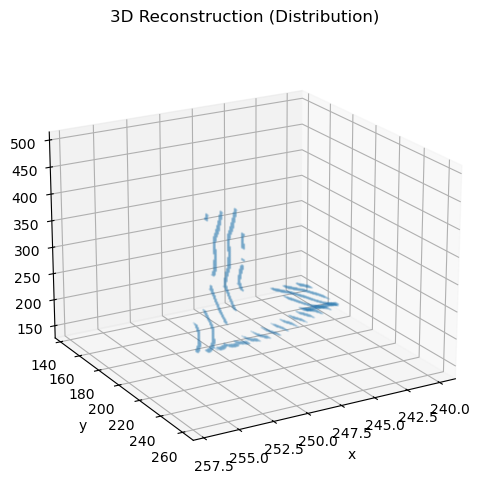

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points[:,0], points[:,1], points[:,2],
           s=0.5, alpha=0.1)

ax.view_init(elev=20, azim=60)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D Reconstruction (Distribution)")

plt.show()

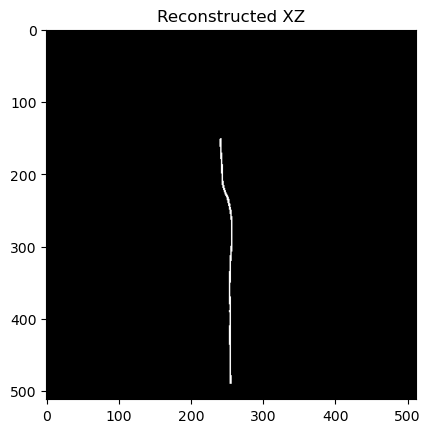

In [6]:
reconstructed_xz = np.zeros_like(bin_xz)

for x, y, z in points:
    reconstructed_xz[int(z), int(x)] = 1

plt.imshow(reconstructed_xz, cmap='gray')
plt.title("Reconstructed XZ")
plt.show()

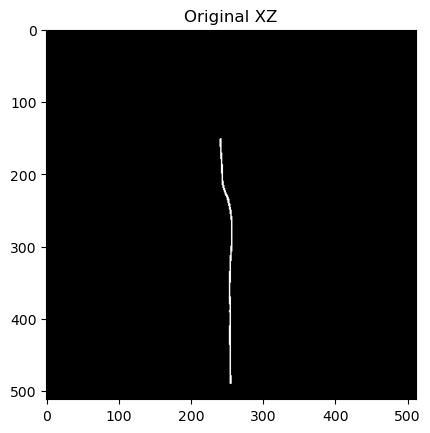

In [8]:
plt.imshow(bin_xz, cmap='gray')
plt.title("Original XZ")
plt.show()

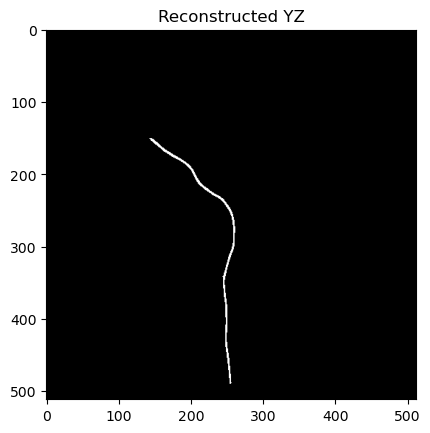

In [7]:
reconstructed_yz = np.zeros_like(bin_yz)

for x, y, z in points:
    reconstructed_yz[int(z), int(y)] = 1

plt.imshow(reconstructed_yz, cmap='gray')
plt.title("Reconstructed YZ")
plt.show()

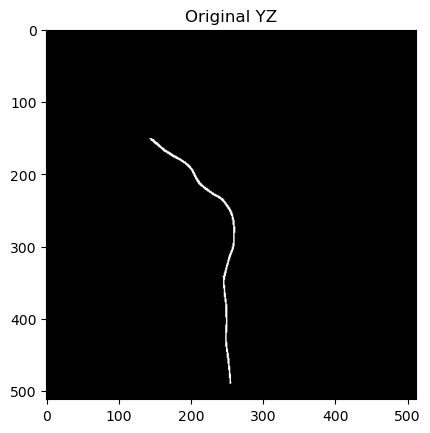

In [9]:
plt.imshow(bin_yz, cmap='gray')
plt.title("Original YZ")
plt.show()

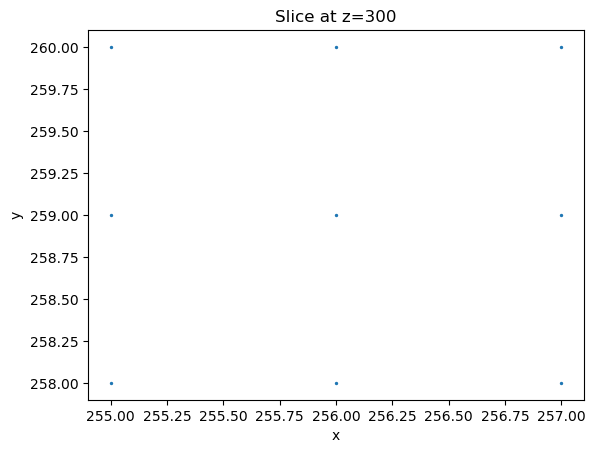

In [12]:
# Single slice 
z0 = 300  # pick some z

slice_pts = points[points[:,2] == z0]

plt.scatter(slice_pts[:,0], slice_pts[:,1], s=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Slice at z={z0}")
plt.show()